# Simulating dynamics on flat plane

## Setup

In [ ]:
using ddHodge
using GLMakie, GraphMakie, LinearAlgebra, NLsolve
using StatsBase: sample, mean, median, std, quantile, msd, rmsd

@isdefined(Dynamical2D) || include("../tools/Dynamical2D.jl")
using .Dynamical2D
using .Dynamical2D: spa, SurfaceFun.sphere

### Set graphic theme

In [13]:
forPrint = false # white background and SVG
if forPrint
    # for figure
    import CairoMakie
    CairoMakie.activate!(type="svg")
    set_theme!( 
        theme_minimal(),fontsize=14,fonts=(;regular="Helvetica"),
        Axis=(xticksvisible=true,yticksvisible=true,)
    )
else
    # for daily use
    GLMakie.activate!(px_per_unit=1)
    set_theme!(
        theme_black(),
        backgroundcolor=RGBf([40,42,54]/255...),
        Colorbar = (spinewidth=0,),
        Legend = (backgroundcolor=:transparent,framevisible=false)
    )
end
#Makie.theme(:fonts)
Makie.inline!(true)

true

## Dynamical system

In [14]:
U(x,y) = exp(-((x+1/2)^2+(y+1/2)^2)/2) - exp(-((x-1/2)^2+(y-1/2)^2)/2)
fg(x,y) = -∇(U)(x,y) # gradient part
fc(x,y) = [0.0, 0.0] # -Q*fg(x,y) # rotation

fp(x,y) = fg(x,y) + fc(x,y) # vector field on parameter space
Jf(x,y) = D(fg)(x,y)

fps = sort([nlsolve(spa(fp),x).zero for x in [[0.5,0.5],[-0.5,-0.5]]])
#fps = sort([nlsolve(spa(fp),x).zero for x in [[1,0.5],[-1,0.5]]])

2-element Vector{Vector{Float64}}:
 [-0.7717023191948433, -0.7717023191948433]
 [0.7717023191948433, 0.7717023191948433]

## ddHodge

[ Info: (1/4) Potential estimation
[ Info: ... done in 0.001 sec.


  0.006333 seconds (46.87 k allocations: 3.545 MiB)
msd(ddh.u .- median(ddh.u), (spa(U)).(ps) .- median((spa(U)).(ps))) = 

[ Info: (2/4) Tangent space estimation
[ Info: Consistency of orientations: 1.0
[ Info: ... done in 0.001 sec.
[ Info: (3/4) Hessian matrix estimation
[ Info: ... done in 0.001 sec.
[ Info: (4/4) Jacobian matrix estimation
[ Info: Consistency of orientations (plane): 1.0
[ Info: ... done in 0.002 sec.


0.0010484975006540569


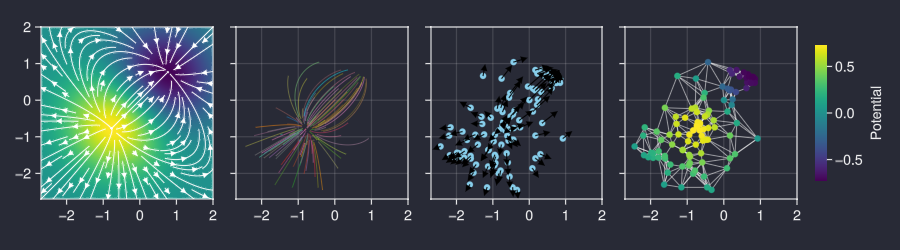

In [15]:
#GLMakie.activate!()
import Random
Random.seed!(111)
fig, p2, g, ddh = let resol=80, smax=40, nt=100, vmax=2, vmin=-2.7, k=6
    xs = LinRange(vmin,vmax,resol)
    fig = Figure(size=(900,250))
    axs = [Axis(fig[1,i],aspect=1) for i in 1:4]
    plt = heatmap!(axs[1],xs,xs,U.(xs,xs'),interpolate=true)
    streamplot!(axs[1], Point2f ∘ spa(fp),vmin..vmax,vmin..vmax,arrow_size=8,linewidth=1,colormap=[:white],density=0.8)
    trajs = [Point2f.(eachcol(kutta(spa(fp),fps[1].+0.2randn(2),dt=0.1,s=sample(1:smax)))) for _ in 1:nt]
    series!(axs[2],trajs,color=resample_cmap(:tab10,nt),linewidth=0.5)
    ps = last.(trajs)
    vs = spa(fp).(ps)
    g, kdtree, = kNNGraph(hcat(ps...),k)
    @time ddh = ddHodgeWorkflow(g,hcat(ps...),hcat(vs...),rdim=2,λ=0.1,ssa=false,krytol=1e-48,useCUDA=false)
    scatter!(axs[3],ps,color=:skyblue)
    quiver!(axs[3],ps,0.5vs)
    #scatter!(axs[4],ps,color=ddh.u)
    graphplot!(axs[4],g,layout=Point2f.(ps),node_color=ddh.u,edge_width=0.5)
    Colorbar(fig[1,5],plt,height=Relative(0.7),label="Potential")
    [begin xlims!(axs[i],vmin,vmax); ylims!(axs[i],vmin,vmax) end for i in 1:4]
    [axs[i].yticklabelsvisible=false for i in 2:4]
    linkaxes!(axs...)
    @show msd(ddh.u .- median(ddh.u),spa(U).(ps) .- median(spa(U).(ps)))
    fig, ps, g, ddh
end
N = length(p2)
X = hcat(p2...)
V = hcat(spa(fp).(p2)...)
fig

## Discrete exterior calculus

In [16]:
using SparseArrays
using KrylovKit: linsolve
import Triangulate, ddHodge.DEC

function DECWorkflow(X,V)
    dl = DEC.delaunayGraph(X)
    dg = dl.graph
    d0 = ddHodge.graphgrad(dg)
    vdual, edual = DEC.stardiags(dg,hcat(p2...),dl.triangles)
    w = ddHodge.calcwt(dg,X,V)
    # Diagonal hodge stars
    s0 = spdiagm(vdual) # ★₀
    s1 = spdiagm(edual) # ★₁
    #d0a = -(s0\d0')*s1 # adjoint, divergence
    d0a = -s0\d0's1 # adjoint, divergence
    #u, = linsolve(-d0'*s1*d0,d0'*s1*w,issymmetric=true)
    u, = linsolve(d0a*d0,-d0a*w,issymmetric=true)
    # Solve Poisson eq. by least square w/o hodge star ★₁
    #u, = linsolve(-d0'*d0,d0'*w,issymmetric=true)
    (g=dg,u=u,d0=d0,d0a=d0a,d1=dl.curl,s0=s0,s1=s1,w=w,div=d0a*w)
end

dec = DECWorkflow(X,V)

(g = Graphs.SimpleGraphs.SimpleGraph{Int32}(284, Vector{Int32}[[30, 57, 71, 77, 83], [31, 32, 48, 52], [9, 45, 46, 53, 56, 73, 88], [9, 45, 86, 95], [34, 41, 47, 76], [25, 41, 44, 47, 68, 97], [22, 39, 40, 75, 87, 88, 93], [28, 42, 69, 74], [3, 4, 20, 29, 45, 56, 58, 72, 95], [37, 39, 59, 66, 67, 99]  …  [21, 62, 74, 82], [19, 30, 66, 96, 98, 99], [7, 15, 40, 53, 73, 88], [54, 84, 86, 95, 100], [4, 9, 17, 54, 72, 86, 94], [19, 65, 76, 81, 92, 98], [6, 25, 68, 78], [30, 65, 77, 92, 96], [10, 19, 43, 66, 67, 92], [17, 54, 60, 70, 94]]), u = [0.2386046150319945, -0.052839987460163336, 0.18977715009155727, -0.09357889466506913, -0.11599084539347036, -0.2112033793575467, 0.39046027710261705, -1.4636904669586441, -0.3002418759033322, 0.2938551194206908  …  0.22569615473785212, 0.24618908241752221, 0.31705257131184233, -0.5505844484189771, -0.5864436789607886, 0.08946611858647377, -0.24418271956188248, 0.1309833733748172, 0.2834923744965782, -1.0844889410153724], d0 = sparse([1, 2, 3, 4, 5, 6

msd(adiv, ddh.div) = 0.025949317172529823
msd(adiv, dec.div) = 3.9907177761219135


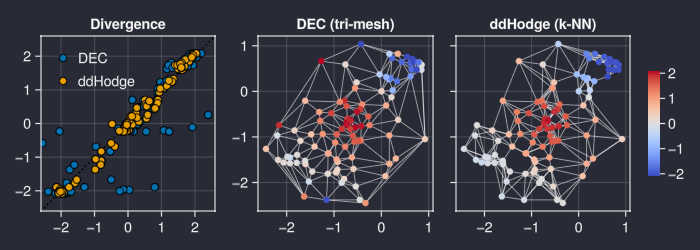

In [17]:
#CairoMakie.activate!(type="svg")
#GLMakie.activate!()
adiv = tr.(spa(Jf).(p2)) # analytical

## Discrete exterior calculus
let rlim = [-2.6,2.6]
    @show msd(adiv, ddh.div)
    @show msd(adiv, dec.div)
    fig = Figure(size=(700,250))
    titles = ["Divergence","DEC (tri-mesh)","ddHodge (k-NN)"]
    axs = [Axis(fig[1,i],aspect=1,title=titles[i]) for i in 1:3]
    #linesegments!(axs[1],collect(zip(Point2f.(dec.div,adiv),Point2f.(ddh.div,adiv))),linewidth=0.2,color=:grey)
    #arrows!(axs[1],Point2f.(dec.div,adiv),0.8Vec2f.(ddh.div-dec.div,0),linewidth=1,color=:grey)
    ablines!(axs[1],0,1,color=:black,linestyle=:dot)
    scatter!(axs[1],dec.div,adiv,strokewidth=1,label="DEC")
    scatter!(axs[1],ddh.div,adiv,strokewidth=1,label="ddHodge")
    axislegend(axs[1],position=:lt,) #framevisible=true,framecolor=:lightgrey)
    xlims!(axs[1],rlim...)
    ylims!(axs[1],rlim...)
    vlim = maximum(abs.(adiv))*[-1,1]
    dgplot!(ax,g,vals) =
        graphplot!(
            ax,g,layout=p2,node_color=vals,
            edge_width=0.5,colormap=:coolwarm,
            node_attr=(colormap=:coolwarm,colorrange=vlim)
        )
    dgplot!(axs[2],dec.g,dec.div)
    dgplot!(axs[3],g,ddh.div)
    Colorbar(fig[1,4],colormap=:coolwarm,colorrange=vlim,height=Relative(0.6))
    linkaxes!(axs[2:3]...)
    axs[3].yticklabelsvisible=false
    fig
end

sum(use) = 99
msd(ddh.div[use], adiv[use]) = 0.026129695101509903
msd(dec.div[use], adiv[use]) = 0.5021116131815607


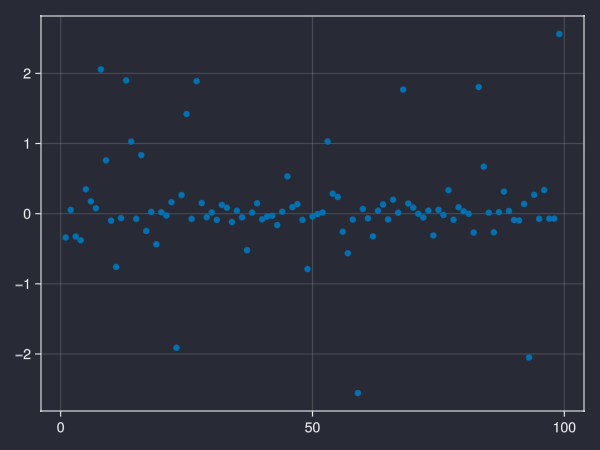

In [18]:
let 
    use = ddHodge.Graphs.degree(dec.g) .>= 6
    use = abs.(dec.div) .< 5
    @show sum(use)
    @show msd(ddh.div[use],adiv[use])
    @show msd(dec.div[use],adiv[use])
    scatter((dec.div-ddh.div)[use])
end


## Performance evaluation

In [19]:
import Logging
#stdout_orig = stdout
#redirect_stdout(devnull)
Logging.disable_logging(Logging.Info)
res = map(1:100) do i
    k=6; smax=40; nt=100
    ps = [Point2f(kutta(spa(fp),fps[1].+0.2randn(2),dt=0.1,s=sample(1:smax))[:,end]) for _ in 1:nt]
    vs = spa(fp).(ps)
    X = hcat(ps...)
    V = hcat(vs...)
    dec = DECWorkflow(X,V)
    g, kdtree, = kNNGraph(X,k)
    ddh = ddHodgeWorkflow(g,X,V,rdim=2,λ=0.1,ssa=false,krytol=1e-48)
    (
        ps = ps,
        connected = ddHodge.Graphs.is_connected(g),
        u = spa(U).(ps),
        div = tr.(spa(Jf).(ps)), # analytical
        udec = dec.u,
        uddh = ddh.u,
        divdec = dec.div,
        divddh = ddh.div,
        ddh=ddh, dec=dec,
    )
end
Logging.disable_logging(Logging.Debug)
#redirect_stdout(stdout_orig)
res = filter(r -> r.connected, res);

[f(mses) for f = [mean, median, std]] = [0.0010489411957828993, 0.0008220376871138017, 0.000962621646931078]
length(labs) = 9900


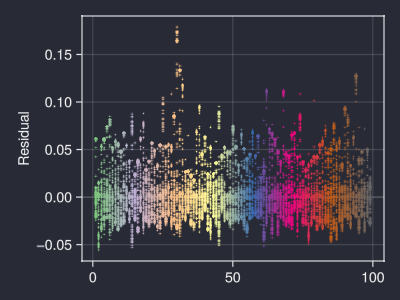

In [20]:
fig, resids, rmses = let
    resids = [let resid = re.uddh - re.u; resid .- median(resid) end for re in res]
    #resids = [re.ddh.d0*(ddh.u - re.u) for re in res]
    #resids = [re.divddh - re.div for re in res]
    mse = x -> mean(abs2.(x))
    mses = mse.(resids)
    @show [f(mses) for f in [mean,median,std]]
    n = length(res)
    labs = repeat(1:n,inner=length(resids[1]))
    @show length(labs)
    pal = resample_cmap(:Accent,n)
    cols = pal[indexin(labs, unique(labs))]
    fig = Figure(size=(400,300))
    ax = Axis(fig[1,1],ylabel="Residual")
    hlines!(ax,[0],color=:grey,linewidth=0.5)
    rainclouds!(ax,labs,vcat(resids...),clouds=nothing,plot_boxplots=false,color=cols)
    fig, resids, mses
end
fig

## Visualization of ddHodge's Hessian matrix estimation

2×4 Matrix{Float64}:
 -1.82477     0.0412066  -2.0   0.0
  0.0412066  -1.87404     0.0  -2.0

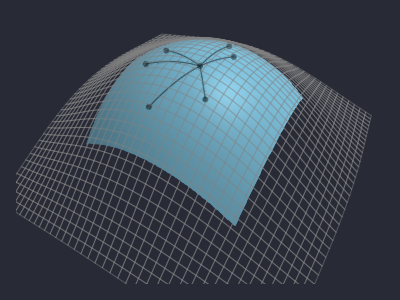

In [21]:
import ForwardDiff
GLMakie.activate!()
fig = let np = 6, trsp=true, lc=:black
    uxs = LinRange(-1,1,40)
    qxs = LinRange(-0.5,0.5,20)
    μ = [0,0]
    #U = (x,y) -> -([x,y]-μ)'*([x,y]-μ)
    U = (x,y) -> exp(-([x,y]-μ)'*[1 0; 0 1]*([x,y]-μ))
    #U = (x,y) -> U(x-μ[1],y-μ[2])
    onsuf = (f,x) -> Point3f(x...,f(x...))
    F(x,y) = -∇(U)(x,y)
    Random.seed!(123)
    ηs = [0.2randn(2) for _ in 1:np]
    ∂1s = [normalize(η)'*F(η...) for η in ηs] # = ∂ₓ a(x-c)²+b = 2a(x-c)
    ∂2s = [η'*(F(0,0)-F(η...))/(η'η) for η in ηs] # = ∂ₓₓ a(x-c)²+b = 2a
    M = hcat(ddHodge.chesse.(normalize.(ηs))...)
    W = I #diagm(norm.(ηs).^-1)
    H0 = ddHodge.chesse2mat((M*W*M')\(M*W*∂2s),2)
    display([H0 ForwardDiff.hessian(spa(U),[0,0])])
    Q = (x,y) -> U(0,0) - F(0,0)'*[x,y] + 0.5*[x,y]'*H0*[x,y]
    #sec = (a,c) -> (x,y) -> let x=norm([x,y]); a*(x-c)^2 + U(p0...); end
    fig = Figure(size=(400,300))
    ax = LScene(fig[1,1],show_axis=false) #azimuth=-pi/4,elevation=pi/4,aspect=:equal)
    #surface!(ax,uxs,uxs,U.(uxs,uxs'),colormap=[:white],transparency=trsp,shading=MultiLightShading)
    wireframe!(ax,uxs,uxs,U.(uxs,uxs'),color=:grey,transparency=trsp,linewidth=0.5)
    #wireframe!(ax,qxs,qxs,Q.(qxs,qxs'),transparency=true,linewidth=0.5,color=:white)
    surface!(ax,qxs,qxs,Q.(qxs,qxs'),colormap=[:skyblue],transparency=trsp,shading=MultiLightShading)
    scatter!(ax,onsuf.(U,[[Point2f(0)];ηs]),color=lc,markersize=8,transparency=trsp)
    for η in ηs
        L = norm(η)
        traj = [Point3f(x*η/L...,U(x*η/L...)) for x in LinRange(0,L,40)]
        lines!(ax,traj,color=lc,linewidth=1,transparency=trsp)
    end
    #rect = Rect2f(0,0,0.5,0.5)
    #mesh!(ax,rect,transformation=(:yz,0),transparency=true,color=:white)
    cam3d!(ax.scene, center=false)
    #translate!(ax.scene,Vec3f(0,0,2))
    eyepos = Vec3f(sphere(-60pi/180,60pi/180,r=2.5))
    update_cam!(ax.scene, eyepos, Vec3f(0,0,0.2), Vec3f(0,0,1))
    fig
end